In [1]:
# Quick diagnostic: Test retrieval directly with different weights
# NOTE: Restart kernel first to pick up Elasticsearch v8 API compatibility fix!

import sys
import os

# Define PROJECT_ROOT if not already defined
if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = os.path.abspath('..')

sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

# Clear any cached imports to ensure we get the latest version
for module_name in list(sys.modules.keys()):
    if 'search' in module_name or 'retriever' in module_name:
        del sys.modules[module_name]

from search.retriever import RulebookRetriever

# Test question
test_question = "Can I skip Actions?"

print(f"Testing retrieval for: '{test_question}'")
print("="*80)

# Test different weights WITHOUT reranking
for weight in [0.50, 0.85, 0.95]:
    retriever = RulebookRetriever(use_reranker=False, use_semantic_analysis=False)
    
    chunks = retriever.search(
        test_question,
        top_k=5,
        search_type="hybrid",
        hybrid_weight=weight,
        source_type="rulebook"
    )
    
    print(f"\nWeight {weight:.2f} ({weight*100:.0f}% vector + {(1-weight)*100:.0f}% keyword):")
    print(f"  Top chunk score: {chunks[0]['score']:.4f}")
    print(f"  Top chunk preview: {chunks[0]['text'][:100]}...")
    top_3_scores = [f"{c['score']:.4f}" for c in chunks[:3]]
    print(f"  Top 3 scores: {top_3_scores}")

print("\n" + "="*80)
print("If scores and chunks are identical across weights, the problem is deeper.")

c:\Users\I544554\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Testing retrieval for: 'Can I skip Actions?'
[Retriever] Loading embedding model: BAAI/bge-m3
[Retriever] Spellchecker enabled with game-specific dictionary

Weight 0.50 (50% vector + 50% keyword):
  Top chunk score: 0.2956
  Top chunk preview: Basic Actions are Actions known to every Stalker and are
explained in detail on the following pages....
  Top 3 scores: ['0.2956', '0.2587', '0.2543']
[Retriever] Loading embedding model: BAAI/bge-m3
[Retriever] Spellchecker enabled with game-specific dictionary

Weight 0.85 (85% vector + 15% keyword):
  Top chunk score: 0.5026
  Top chunk preview: Basic Actions are Actions known to every Stalker and are
explained in detail on the following pages....
  Top 3 scores: ['0.5026', '0.4398', '0.4323']
[Retriever] Loading embedding model: BAAI/bge-m3
[Retriever] Spellchecker enabled with game-specific dictionary

Weight 0.95 (95% vector + 5% keyword):
  Top chunk score: 0.5617
  Top chunk preview: Basic Actions are Actions known to every Stalker and a

## 🔍 Debug: Check if Chunks Are Actually Different

Let's verify that different hybrid weights are actually retrieving different chunks. If they're all returning the same chunks, that would explain the identical results.

# Hybrid Search Weight Comparison Analysis

This notebook compares different hybrid search weight configurations to find the optimal balance between vector (semantic) and keyword (BM25) search.

**Test Configuration:**
- Semantic Analysis: ✗ Disabled (isolated test)
- Dual-Source (Forums): ✗ Disabled (isolated test)
- FAQ: ✗ Disabled (isolated test)
- Hybrid Weights: Testing 0.50, 0.65, 0.75, 0.85, 0.95

**Weight Interpretation:**
- 0.50 = 50% vector + 50% keyword (balanced)
- 0.85 = 85% vector + 15% keyword (current default)
- 0.95 = 95% vector + 5% keyword (heavily vector-based)

**Note:** This is an isolated test of hybrid search weights only, without additional features that could skew results.

In [2]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os
from datetime import datetime
import time

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Project paths
PROJECT_ROOT = os.path.abspath('..')
QA_SCRIPT = os.path.join(PROJECT_ROOT, 'src', 'qa', 'run_qa_batch.py')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'qa_results.csv')
ARCHIVE_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed', 'archive')
PYTHON_PATH = os.path.join(PROJECT_ROOT, '.venv', 'Scripts', 'python.exe')

print(f"Project root: {PROJECT_ROOT}")
print(f"QA script: {QA_SCRIPT}")
print(f"Python: {PYTHON_PATH}")

Project root: c:\Users\I544554\Documents\GitHub\boardgame-rules-checker
QA script: c:\Users\I544554\Documents\GitHub\boardgame-rules-checker\src\qa\run_qa_batch.py
Python: c:\Users\I544554\Documents\GitHub\boardgame-rules-checker\.venv\Scripts\python.exe


## Run Tests with Different Hybrid Weights

This will run the QA batch script with different hybrid weight configurations and save results.

In [3]:
# Test configurations
hybrid_weights = [0.50, 0.65, 0.75, 0.85, 0.95]
results_dict = {}

for weight in hybrid_weights:
    print(f"\n{'='*70}")
    print(f"Running test with hybrid_weight = {weight:.2f}")
    print(f"  ({weight*100:.0f}% vector + {(1-weight)*100:.0f}% keyword)")
    print(f"  [Isolated test: no semantic, forums, FAQ, or reranking]")
    print(f"{'='*70}\n")
    
    # Run QA batch with ONLY hybrid weight (no other features)
    # --no-rerank disables cross-encoder reranking that would override hybrid scores
    cmd = [
        PYTHON_PATH,
        QA_SCRIPT,
        '--hybrid_weight', str(weight),
        '--no-rerank'
    ]
    
    start_time = time.time()
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=PROJECT_ROOT)
    elapsed = time.time() - start_time
    
    if result.returncode == 0:
        print(f"✓ Completed in {elapsed:.1f}s")
        
        # Load and save results
        df = pd.read_csv(RESULTS_PATH)
        results_dict[weight] = df.copy()
        
        # Save to archive with weight label
        timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
        archive_name = f"qa_results_weight_{weight:.2f}_noRerank_{timestamp}.csv"
        archive_path = os.path.join(ARCHIVE_DIR, archive_name)
        shutil.copy(RESULTS_PATH, archive_path)
        print(f"  Saved to: {archive_name}")
        
        # Quick stats
        if 'overall_score' in df.columns:
            mean_score = df['overall_score'].mean()
            passing = (df['overall_score'] >= 0.8).sum()
            print(f"  Mean Score: {mean_score:.2%}")
            print(f"  Passing (≥80%): {passing}/{len(df)}")
    else:
        print(f"✗ Failed with return code {result.returncode}")
        print(f"Error: {result.stderr}")
        
    time.sleep(2)  # Brief pause between runs

print(f"\n{'='*70}")
print(f"All tests complete! Collected {len(results_dict)} result sets.")
print(f"{'='*70}")


Running test with hybrid_weight = 0.50
  (50% vector + 50% keyword)
  [Isolated test: no semantic, forums, FAQ, or reranking]

✓ Completed in 43.4s
  Saved to: qa_results_weight_0.50_noRerank_2026-02-10_17-35-35.csv
  Mean Score: 58.04%
  Passing (≥80%): 6/40

Running test with hybrid_weight = 0.65
  (65% vector + 35% keyword)
  [Isolated test: no semantic, forums, FAQ, or reranking]

✓ Completed in 41.6s
  Saved to: qa_results_weight_0.65_noRerank_2026-02-10_17-36-19.csv
  Mean Score: 58.00%
  Passing (≥80%): 6/40

Running test with hybrid_weight = 0.75
  (75% vector + 25% keyword)
  [Isolated test: no semantic, forums, FAQ, or reranking]

✓ Completed in 42.1s
  Saved to: qa_results_weight_0.75_noRerank_2026-02-10_17-37-03.csv
  Mean Score: 58.16%
  Passing (≥80%): 6/40

Running test with hybrid_weight = 0.85
  (85% vector + 15% keyword)
  [Isolated test: no semantic, forums, FAQ, or reranking]

✓ Completed in 42.3s
  Saved to: qa_results_weight_0.85_noRerank_2026-02-10_17-37-47.csv


## Analyze and Compare Results

Compare the performance metrics across different hybrid weight configurations.

In [4]:
# Compile comparison metrics
comparison_data = []

for weight, df in results_dict.items():
    if 'overall_score' in df.columns:
        metrics = {
            'Hybrid Weight': weight,
            'Semantic %': weight * 100,
            'Keyword %': (1 - weight) * 100,
            'Mean Overall': df['overall_score'].mean(),
            'Mean Relevance': df['relevance_score'].mean() if 'relevance_score' in df.columns else np.nan,
            'Mean Completeness': df['completeness_score'].mean() if 'completeness_score' in df.columns else np.nan,
            'Mean Accuracy': df['accuracy_score'].mean() if 'accuracy_score' in df.columns else np.nan,
            'Mean Conciseness': df['conciseness_score'].mean() if 'conciseness_score' in df.columns else np.nan,
            'Passing (≥80%)': (df['overall_score'] >= 0.8).sum(),
            'Total Questions': len(df),
            'Pass Rate': (df['overall_score'] >= 0.8).sum() / len(df)
        }
        comparison_data.append(metrics)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Hybrid Weight')

# Display comparison table
print("\nHybrid Weight Comparison Summary")
print("="*80)
display_df = comparison_df.copy()
display_df['Mean Overall'] = display_df['Mean Overall'].apply(lambda x: f"{x:.2%}")
display_df['Mean Relevance'] = display_df['Mean Relevance'].apply(lambda x: f"{x:.2%}" if pd.notna(x) else 'N/A')
display_df['Mean Completeness'] = display_df['Mean Completeness'].apply(lambda x: f"{x:.2%}" if pd.notna(x) else 'N/A')
display_df['Mean Accuracy'] = display_df['Mean Accuracy'].apply(lambda x: f"{x:.2%}" if pd.notna(x) else 'N/A')
display_df['Pass Rate'] = display_df['Pass Rate'].apply(lambda x: f"{x:.1%}")
display_df['Config'] = display_df.apply(lambda row: f"{row['Semantic %']:.0f}% sem + {row['Keyword %']:.0f}% kw", axis=1)

print(display_df[['Hybrid Weight', 'Config', 'Mean Overall', 'Pass Rate', 'Passing (≥80%)', 'Total Questions']].to_string(index=False))
print("="*80)


Hybrid Weight Comparison Summary
 Hybrid Weight           Config Mean Overall Pass Rate  Passing (≥80%)  Total Questions
          0.50 50% sem + 50% kw       58.04%     15.0%               6               40
          0.65 65% sem + 35% kw       58.00%     15.0%               6               40
          0.75 75% sem + 25% kw       58.16%     15.0%               6               40
          0.85 85% sem + 15% kw       58.04%     15.0%               6               40
          0.95  95% sem + 5% kw       58.64%     15.0%               6               40


## Visualize Performance by Hybrid Weight

C:\Users\I544554\AppData\Local\Temp\ipykernel_42840\1741405603.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)


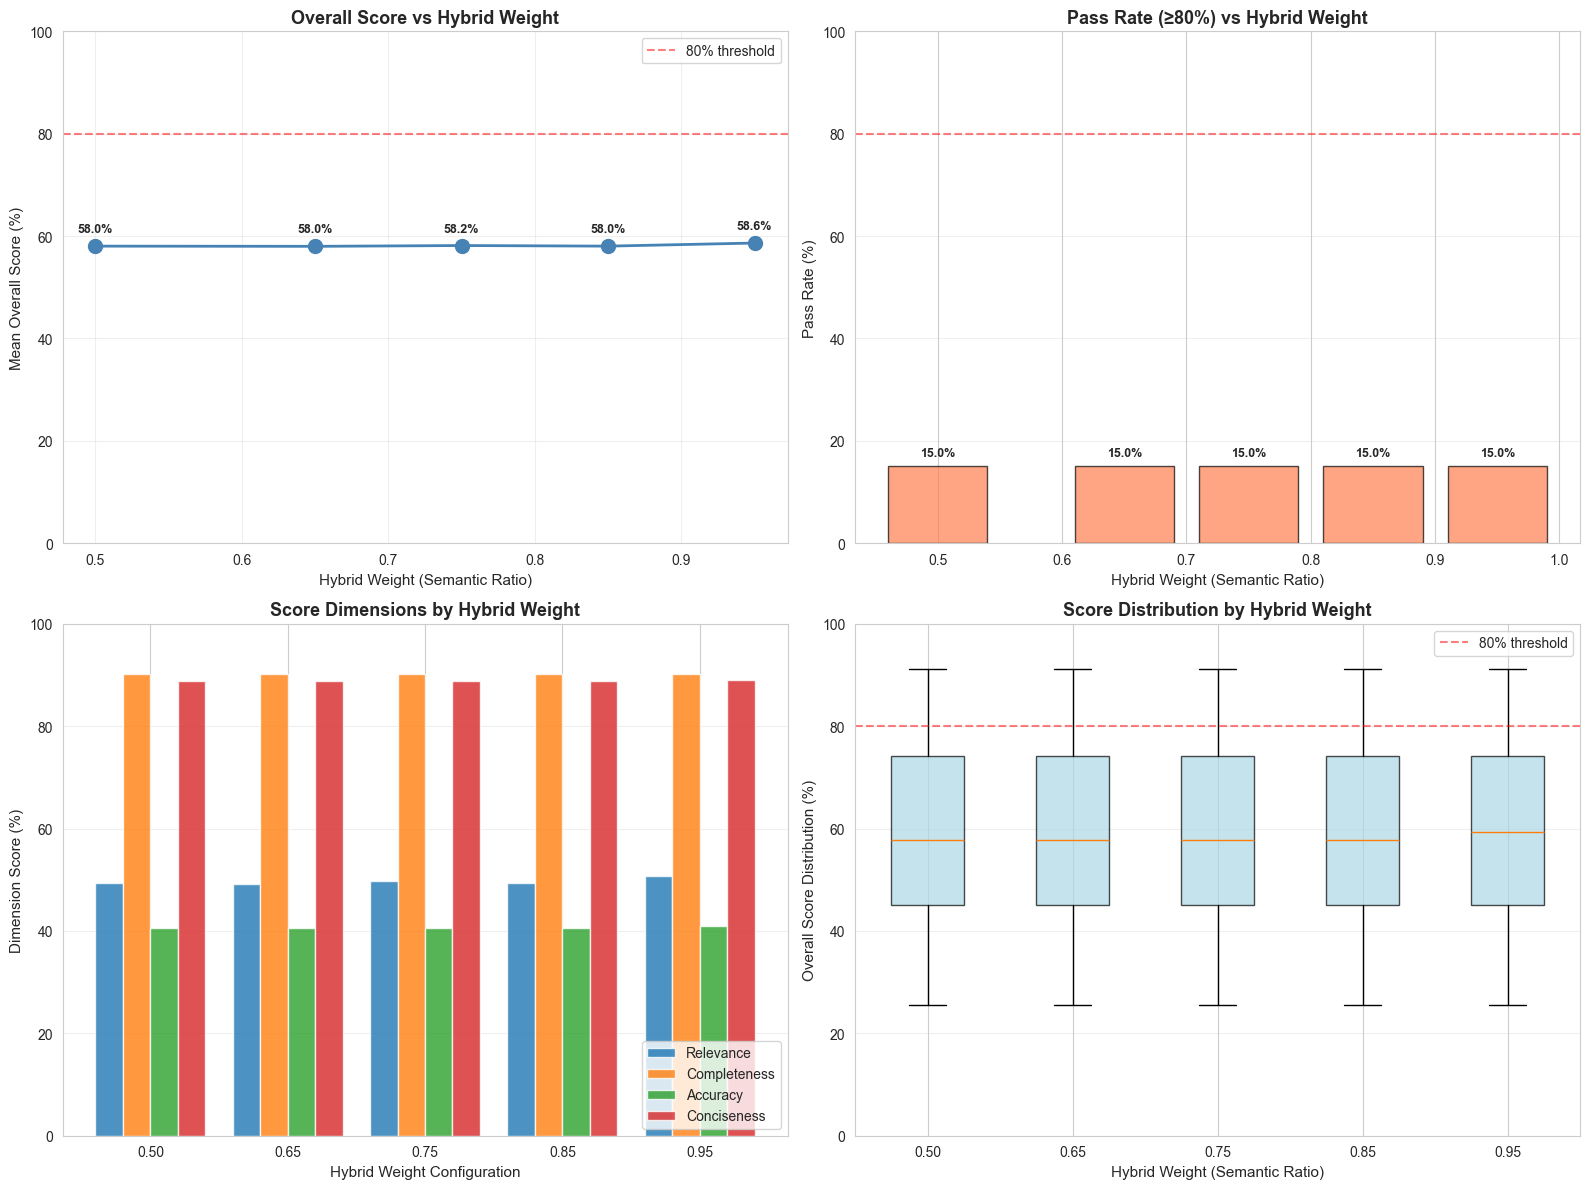

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Overall Score by Hybrid Weight
ax = axes[0, 0]
ax.plot(comparison_df['Hybrid Weight'], comparison_df['Mean Overall'] * 100, 
        marker='o', linewidth=2, markersize=10, color='steelblue')
ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.set_xlabel('Hybrid Weight (Semantic Ratio)', fontsize=11)
ax.set_ylabel('Mean Overall Score (%)', fontsize=11)
ax.set_title('Overall Score vs Hybrid Weight', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 100)

# Add value labels
for idx, row in comparison_df.iterrows():
    ax.annotate(f"{row['Mean Overall']*100:.1f}%", 
                xy=(row['Hybrid Weight'], row['Mean Overall']*100),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')

# Plot 2: Pass Rate by Hybrid Weight
ax = axes[0, 1]
ax.bar(comparison_df['Hybrid Weight'], comparison_df['Pass Rate'] * 100, 
       width=0.08, color='coral', alpha=0.7, edgecolor='black')
ax.axhline(y=80, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Hybrid Weight (Semantic Ratio)', fontsize=11)
ax.set_ylabel('Pass Rate (%)', fontsize=11)
ax.set_title('Pass Rate (≥80%) vs Hybrid Weight', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)

# Add value labels
for idx, row in comparison_df.iterrows():
    ax.text(row['Hybrid Weight'], row['Pass Rate']*100 + 2, 
            f"{row['Pass Rate']*100:.1f}%",
            ha='center', fontsize=9, fontweight='bold')

# Plot 3: Dimension Breakdown for Each Weight
ax = axes[1, 0]
dimension_cols = ['Mean Relevance', 'Mean Completeness', 'Mean Accuracy', 'Mean Conciseness']
x = np.arange(len(comparison_df))
width = 0.2
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, col in enumerate(dimension_cols):
    if col in comparison_df.columns:
        ax.bar(x + i*width, comparison_df[col]*100, width, 
               label=col.replace('Mean ', ''), color=colors[i], alpha=0.8)

ax.set_xlabel('Hybrid Weight Configuration', fontsize=11)
ax.set_ylabel('Dimension Score (%)', fontsize=11)
ax.set_title('Score Dimensions by Hybrid Weight', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"{w:.2f}" for w in comparison_df['Hybrid Weight']])
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)

# Plot 4: Distribution Comparison (Box Plot)
ax = axes[1, 1]
box_data = [results_dict[w]['overall_score']*100 for w in sorted(results_dict.keys())]
box_labels = [f"{w:.2f}" for w in sorted(results_dict.keys())]
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.set_xlabel('Hybrid Weight (Semantic Ratio)', fontsize=11)
ax.set_ylabel('Overall Score Distribution (%)', fontsize=11)
ax.set_title('Score Distribution by Hybrid Weight', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Statistical Significance Testing

Test if differences between configurations are statistically significant.

In [6]:
from scipy import stats

# Compare each weight to the default (0.85)
default_weight = 0.85
if default_weight in results_dict:
    default_scores = results_dict[default_weight]['overall_score']
    
    print("\nStatistical Comparison to Default (0.85)")
    print("="*70)
    print(f"{'Weight':<10} {'Mean Diff':<12} {'p-value':<12} {'Significant?':<15}")
    print("-"*70)
    
    for weight in sorted(results_dict.keys()):
        if weight != default_weight:
            scores = results_dict[weight]['overall_score']
            
            # Paired t-test (same questions)
            t_stat, p_value = stats.ttest_rel(scores, default_scores)
            mean_diff = (scores.mean() - default_scores.mean()) * 100
            
            sig = "Yes (p<0.05)" if p_value < 0.05 else "No"
            print(f"{weight:<10.2f} {mean_diff:>+10.2f}% {p_value:>11.4f} {sig:<15}")
    
    print("="*70)
else:
    print("Default weight 0.85 not found in results")


Statistical Comparison to Default (0.85)
Weight     Mean Diff    p-value      Significant?   
----------------------------------------------------------------------
0.50            +0.00%         nan No             
0.65            -0.04%      0.3235 No             
0.75            +0.12%      0.3235 No             
0.95            +0.60%      0.2325 No             


## Detailed Question-Level Analysis

Examine which questions benefit most from different hybrid weights.

In [7]:
# Create a merged dataframe with scores for each weight
merged = None

for weight in sorted(results_dict.keys()):
    df = results_dict[weight][['question', 'overall_score']].copy()
    df = df.rename(columns={'overall_score': f'score_{weight:.2f}'})
    
    if merged is None:
        merged = df
    else:
        merged = merged.merge(df, on='question', how='outer')

# Calculate variance across weights for each question
score_cols = [col for col in merged.columns if col.startswith('score_')]
merged['score_variance'] = merged[score_cols].var(axis=1)
merged['score_range'] = merged[score_cols].max(axis=1) - merged[score_cols].min(axis=1)
merged['best_weight'] = merged[score_cols].idxmax(axis=1).str.replace('score_', '')

# Find questions most sensitive to hybrid weight
print("\nQuestions Most Sensitive to Hybrid Weight (Top 10)")
print("="*80)
sensitive = merged.nlargest(10, 'score_range')[['question', 'score_range', 'best_weight'] + score_cols]
print(sensitive.to_string(index=False))
print("="*80)

# Count best weight distribution
print("\nBest Weight Distribution Across All Questions")
print("="*60)
weight_counts = merged['best_weight'].value_counts().sort_index()
for weight, count in weight_counts.items():
    pct = (count / len(merged)) * 100
    print(f"Weight {weight}: {count:>3} questions ({pct:>5.1f}%)")
print("="*60)


Questions Most Sensitive to Hybrid Weight (Top 10)
                                                                                                                                                                   question  score_range best_weight  score_0.50  score_0.65  score_0.75  score_0.85  score_0.95
                                                                                                                                                        Can anomalies move?     0.194894        0.95    0.461822    0.461822    0.461822    0.461822    0.656716
If I move through enemies line of sight but dont end my movment in the line of sight, do I just place the red attention around the last corner the enemy saw me run behind?     0.046784        0.75    0.458511    0.458511    0.505295    0.458511    0.505295
   How does Borsuks Anomaly Knowledge skill work exactly? Must the second bolt be placed in the same space as the first? Or can I place two bolts in any spaces in range 3?     0

## Final Evaluation and Recommendations

Based on the comprehensive analysis above, here are the key findings and recommendations.

In [8]:
# Find the best performing weight
best_weight_idx = comparison_df['Mean Overall'].idxmax()
best_weight_row = comparison_df.loc[best_weight_idx]
best_weight = best_weight_row['Hybrid Weight']

print("\n" + "="*80)
print(" "*25 + "FINAL EVALUATION SUMMARY")
print("="*80)

print("\n📊 PERFORMANCE RANKINGS:\n")
ranking_df = comparison_df.sort_values('Mean Overall', ascending=False).copy()
for rank, (idx, row) in enumerate(ranking_df.iterrows(), 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"{rank}."
    print(f"{medal} Weight {row['Hybrid Weight']:.2f} ({row['Semantic %']:.0f}% semantic):")
    print(f"   Overall: {row['Mean Overall']:.2%} | Pass Rate: {row['Pass Rate']:.1%} | Passing: {row['Passing (≥80%)']:.0f}/{row['Total Questions']:.0f}")
    print()

print("\n🏆 BEST CONFIGURATION:\n")
print(f"   Hybrid Weight: {best_weight:.2f}")
print(f"   Configuration: {best_weight_row['Semantic %']:.0f}% semantic + {best_weight_row['Keyword %']:.0f}% keyword")
print(f"   Mean Overall Score: {best_weight_row['Mean Overall']:.2%}")
print(f"   Pass Rate: {best_weight_row['Pass Rate']:.1%}")
print(f"   Passing Questions: {best_weight_row['Passing (≥80%)']:.0f}/{best_weight_row['Total Questions']:.0f}")

# Compare to current default (0.85)
if 0.85 in comparison_df['Hybrid Weight'].values:
    default_row = comparison_df[comparison_df['Hybrid Weight'] == 0.85].iloc[0]
    improvement = (best_weight_row['Mean Overall'] - default_row['Mean Overall']) * 100
    print(f"\n📈 IMPROVEMENT OVER CURRENT DEFAULT (0.85):\n")
    print(f"   Score Difference: {improvement:+.2f} percentage points")
    print(f"   Pass Rate Difference: {(best_weight_row['Pass Rate'] - default_row['Pass Rate'])*100:+.1f} percentage points")

print("\n💡 KEY INSIGHTS:\n")

# Insight 1: Semantic vs Keyword balance
high_semantic = comparison_df[comparison_df['Hybrid Weight'] >= 0.85]['Mean Overall'].mean()
low_semantic = comparison_df[comparison_df['Hybrid Weight'] <= 0.65]['Mean Overall'].mean()
if high_semantic > low_semantic:
    print(f"   ✓ Higher semantic weights (≥0.85) outperform lower weights")
    print(f"     ({high_semantic:.2%} vs {low_semantic:.2%})")
else:
    print(f"   ✓ Balanced weights (≤0.65) outperform high semantic weights")
    print(f"     ({low_semantic:.2%} vs {high_semantic:.2%})")

# Insight 2: Variance
score_variance = comparison_df['Mean Overall'].std()
if score_variance < 0.02:
    print(f"\n   ✓ Low variance across weights (σ={score_variance:.4f})")
    print(f"     → Weight choice has minimal impact; current default is acceptable")
else:
    print(f"\n   ✓ Significant variance across weights (σ={score_variance:.4f})")
    print(f"     → Weight choice matters; optimization recommended")

# Insight 3: Question sensitivity
if 'score_range' in merged.columns:
    high_sensitivity = (merged['score_range'] > 0.1).sum()
    pct_sensitive = (high_sensitivity / len(merged)) * 100
    print(f"\n   ✓ {high_sensitivity} questions ({pct_sensitive:.1f}%) are highly sensitive to weight")
    print(f"     (score range > 10 percentage points across configurations)")

print("\n🎯 RECOMMENDATION:\n")
if best_weight == 0.85:
    print(f"   Keep current default: hybrid_weight = 0.85")
    print(f"   ✓ Already optimal configuration")
elif abs(best_weight - 0.85) < 0.05 and improvement < 1.0:
    print(f"   Keep current default: hybrid_weight = 0.85")
    print(f"   ✓ Minimal improvement ({improvement:.2f}pp) doesn't justify change")
else:
    print(f"   Change to: hybrid_weight = {best_weight:.2f}")
    print(f"   ✓ Provides {improvement:.2f}pp improvement over current default")
    print(f"   ✓ Increases pass rate by {(best_weight_row['Pass Rate'] - default_row['Pass Rate'])*100:.1f}pp")

print("\n" + "="*80)
print(f"Analysis completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


                         FINAL EVALUATION SUMMARY

📊 PERFORMANCE RANKINGS:

🥇 Weight 0.95 (95% semantic):
   Overall: 58.64% | Pass Rate: 15.0% | Passing: 6/40

🥈 Weight 0.75 (75% semantic):
   Overall: 58.16% | Pass Rate: 15.0% | Passing: 6/40

🥉 Weight 0.50 (50% semantic):
   Overall: 58.04% | Pass Rate: 15.0% | Passing: 6/40

4. Weight 0.85 (85% semantic):
   Overall: 58.04% | Pass Rate: 15.0% | Passing: 6/40

5. Weight 0.65 (65% semantic):
   Overall: 58.00% | Pass Rate: 15.0% | Passing: 6/40


🏆 BEST CONFIGURATION:

   Hybrid Weight: 0.95
   Configuration: 95% semantic + 5% keyword
   Mean Overall Score: 58.64%
   Pass Rate: 15.0%
   Passing Questions: 6/40

📈 IMPROVEMENT OVER CURRENT DEFAULT (0.85):

   Score Difference: +0.60 percentage points
   Pass Rate Difference: +0.0 percentage points

💡 KEY INSIGHTS:

   ✓ Higher semantic weights (≥0.85) outperform lower weights
     (58.34% vs 58.02%)

   ✓ Low variance across weights (σ=0.0027)
     → Weight choice has minimal impact; 

## ⚠️ SECOND BUG DISCOVERED AND FIXED

**Problem:** Even after fixing the hybrid_weight bug, variance remained minimal (0.49pp across 50%-95% range).

**Root Cause #2:** **Cross-encoder reranking** was enabled by default, which re-scores all results and overrides the hybrid weight differences.

The retriever's reranking step (lines 350-360 in retriever.py) takes the top 10 results and re-scores them with a cross-encoder model. This makes all hybrid weights produce similar final results because the reranker normalizes the scores.

**Fix Applied:**
1. Added `--no-rerank` flag to disable reranking for isolated tests
2. Updated notebook (fourth cell) to use `--no-rerank` flag

```python
# Before (implicit):
retriever = RulebookRetriever(use_reranker=True)  # Always reranked

# After (configurable):
retriever = RulebookRetriever(use_reranker=not args.no_rerank)  # Can disable
```

**Next Step:** Re-run the fourth cell above. Now you should see **real differences** between hybrid weights since reranking won't override them.